# ViT-B16 with Entropy Filtering, Ordinal Loss, and Focal Loss

This notebook trains an ViT-B16 model combining:
- **Entropy filtering**: Removes high-entropy samples for cleaner training
- **Ordinal loss**: Leverages the ordinal nature of ISUP grades (0 < 1 < 2 < 3 < 4 < 5)
- **Focal loss**: Focuses on hard examples and handles class imbalance

The combination addresses multiple challenges:
1. Ordinal structure ensures predictions respect grade ordering
2. Focal loss down-weights easy examples and focuses on hard misclassifications
3. Entropy filtering removes noisy/ambiguous samples

In [ ]:
from torch import optim
from torchvision.models import vit_b_16, ViT_B_16_Weights
import torch
import random
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import albumentations as Albu
import pandas as pd
from torch.utils.data import DataLoader
from torch.utils.data.sampler import RandomSampler, SequentialSampler
from warmup_scheduler import GradualWarmupScheduler
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, recall_score, precision_score
from tqdm import tqdm
import optuna
from optuna.pruners import MedianPruner
import sys
sys.path.append("../../..")
import os
from utils.dataset import PandasDataset
from utils.models import ViTApi

## Configuration

In [ ]:
# Training parameters
seed = 42
batch_size = 12
num_workers = 4
output_classes = 5  # For ordinal encoding: ISUP 0-5 → 5 thresholds
init_lr = 3e-4
warmup_factor = 2
warmup_epochs = 1
n_epochs = 50
dropout_rate = 0.2
patience = 7

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set seeds
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Paths
ROOT_DIR = '../../..'
data_dir = '../../../..'
images_dir = os.path.join(data_dir, 'tiles')

# Output paths
os.makedirs('../logs', exist_ok=True)
os.makedirs('../models', exist_ok=True)
os.makedirs('logs', exist_ok=True)
os.makedirs('models', exist_ok=True)
model_path = 'models/vit-0.pth'
log_path = 'logs/vit-0.txt'

# ── Optuna ────────────────────────────────────────────────────────────────────
# Subset do train + menos épocas por trial para reduzir custo
OPTUNA_SUBSET_FRAC = 0.25   # fração do train usada em cada trial
N_OPTUNA_TRIALS    = 30     # número de trials
N_OPTUNA_EPOCHS    = 5      # épocas por trial
OPTUNA_BATCH_SIZE  = batch_size

STUDY_DB   = 'sqlite:///logs/vit-entropy-ordinal-focal-optuna.db'
STUDY_NAME = 'vit-entropy-ordinal-focal'

## Combined Ordinal + Focal Loss

This loss function combines:
1. **Ordinal encoding**: Converts ISUP grades to binary thresholds [1,1,...,1,0,0,...,0]
2. **Focal loss modulation**: Applies (1-p_t)^gamma weighting to focus on hard examples

Formula: `FL(p_t) = -alpha * (1 - p_t)^gamma * BCE(logits, ordinal_targets)`

In [ ]:
class FocalOrdinalRegressionLoss(nn.Module):
    def __init__(self, alpha=1.0, beta=1.0, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma

    def focal_loss(self, logits, targets):
        probs = torch.sigmoid(logits)
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        p_t = probs * targets + (1 - probs) * (1 - targets)
        modulation = (1 - p_t) ** self.gamma
        return (modulation * bce).mean()

    def forward(self, logits, targets):
        targets = targets.to(logits.device)
        f_loss = self.focal_loss(logits, targets)
        probs = torch.sigmoid(logits)
        expected_class = torch.sum(probs, dim=1)
        targets_class = torch.sum(targets, dim=1)
        max_class = logits.shape[1]
        ordinal_loss = torch.mean((expected_class - targets_class) ** 2) / (max_class ** 2)
        return self.alpha * f_loss + self.beta * ordinal_loss


def decode_ordinal_predictions(logits):
    probs = torch.sigmoid(logits)
    predictions = (probs > 0.5).sum(dim=1)
    return predictions

print("FocalOrdinalRegressionLoss defined.")

## Load Data with Entropy Filtering

In [5]:
# Load original training data
df_train_ = pd.read_csv(f"{ROOT_DIR}/data/train_5fold.csv")
print(f"Original records: {len(df_train_)}")

# Load entropy filtered samples
df_entropy = pd.read_csv(f"{ROOT_DIR}/data/entropy.csv")
print(f"High-entropy samples to remove: {len(df_entropy)}")

df_entropy_sorted = df_entropy.sort_values(by='difficulty_score', ascending=False).reset_index(drop=True)

n_remove = int(len(df_entropy) * 0.2)

df_entropy_top = df_entropy_sorted.head(n_remove)
# Filter out high-entropy samples
df_train_ = df_train_[~df_train_['image_id'].isin(df_entropy_top['image_id'])].reset_index(drop=True)
print(f"Filtered records: {len(df_train_)}")

# Clean column names
df_train_.columns = df_train_.columns.str.strip()

# Split by fold (fold 3 for validation)
train_indexes = np.where(df_train_['fold'] != 3)[0]
valid_indexes = np.where(df_train_['fold'] == 3)[0]

df_train = df_train_.loc[train_indexes].reset_index(drop=True)
df_val = df_train_.loc[valid_indexes].reset_index(drop=True)

# Load test data
df_test = pd.read_csv(f"{ROOT_DIR}/data/test.csv")

def remove_nonexistent_images(df, images_dir):
    """
    Remove rows from df where the image does not exist in images_dir.
    """
    image_ids = df['image_id'].apply(lambda x: os.path.join(images_dir, f"{x}.png"))
    existent_images = [os.path.isfile(path) for path in image_ids]
    df = df[existent_images]
    return df

df_train = remove_nonexistent_images(df_train, images_dir)
df_val = remove_nonexistent_images(df_val, images_dir)
df_test = remove_nonexistent_images(df_test, images_dir)

print(f"\nTrain: {len(df_train)} samples")
print(f"Validation: {len(df_val)} samples")
print(f"Test: {len(df_test)} samples")

# Check class distribution
print(f"\nTrain class distribution:")
print(df_train['isup_grade'].value_counts().sort_index())

Original records: 9024
High-entropy samples to remove: 903
Filtered records: 8844

Train: 7073 samples
Validation: 1767 samples
Test: 1590 samples

Train class distribution:
isup_grade
0    1953
1    1802
2     899
3     826
4     832
5     761
Name: count, dtype: int64


## Data Augmentation

In [6]:
# Augmentation for training
train_transforms = Albu.Compose([
    Albu.Transpose(p=0.5),
    Albu.VerticalFlip(p=0.5),
    Albu.HorizontalFlip(p=0.5),
    Albu.Resize(
        height=224, width=224
    )
])

# No augmentation for validation/test
val_transforms = Albu.Compose([
    Albu.Resize(
        height=224, width=224
    )
])

## Create Datasets and DataLoaders

In [ ]:
# Create datasets
train_dataset = PandasDataset(images_dir, df_train, transforms=train_transforms, format="png")
valid_dataset = PandasDataset(images_dir, df_val, transforms=val_transforms, format="png")
test_dataset = PandasDataset(images_dir, df_test, transforms=val_transforms, format="png")

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    sampler=RandomSampler(train_dataset),
    pin_memory=True,
    persistent_workers=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    num_workers=num_workers,    
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False
)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(valid_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 590
Validation batches: 148
Test batches: 133


## Busca de Hiperparâmetros com Optuna

O Optuna busca simultaneamente:
- **Loss**: `gamma`, `alpha` (w_focal), `beta` (w_ord) da `FocalOrdinalRegressionLoss`
- **Otimizador**: `lr` (log-scale) e `weight_decay`

Treina por `N_OPTUNA_EPOCHS` épocas com `MedianPruner` e maximiza o **QWK** de validação.

In [ ]:
# Subset fixo do train para o Optuna (reprodutível)
rng_optuna = np.random.default_rng(seed)
optuna_idx = rng_optuna.choice(len(df_train), size=int(len(df_train) * OPTUNA_SUBSET_FRAC), replace=False)
df_optuna  = df_train.iloc[optuna_idx].reset_index(drop=True)

optuna_train_ds = PandasDataset(images_dir, df_optuna, transforms=train_transforms, format="png")
optuna_val_ds   = PandasDataset(images_dir, df_val,    transforms=val_transforms,   format="png")

optuna_train_loader = DataLoader(
    optuna_train_ds,
    batch_size=OPTUNA_BATCH_SIZE,
    num_workers=num_workers,
    sampler=RandomSampler(optuna_train_ds),
    pin_memory=True,
)
optuna_val_loader = DataLoader(
    optuna_val_ds,
    batch_size=OPTUNA_BATCH_SIZE,
    num_workers=num_workers,
    sampler=SequentialSampler(optuna_val_ds),
    pin_memory=True,
)

print(f"Optuna subset: {len(df_optuna)} imgs ({OPTUNA_SUBSET_FRAC:.0%} do train)")
print(f"Train batches: {len(optuna_train_loader)} | Val batches: {len(optuna_val_loader)}")

In [ ]:
def build_model(dr=dropout_rate):
    backbone = vit_b_16(weights=ViT_B_16_Weights.DEFAULT)
    model = ViTApi(model=backbone, output_dimensions=output_classes, dropout_rate=dr)
    return model.to(device)


def optuna_train_one_epoch(model, dataloader, optimizer, loss_fn):
    model.train()
    scaler_opt = torch.amp.GradScaler()
    optimizer.zero_grad()
    for step, (batch_data, batch_targets, _) in enumerate(dataloader):
        batch_data    = batch_data.to(device, non_blocking=True)
        batch_targets = batch_targets.to(device, non_blocking=True)
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            logits = model(batch_data)
            loss   = loss_fn(logits, batch_targets)
        scaler_opt.scale(loss).backward()
        scaler_opt.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler_opt.step(optimizer)
        scaler_opt.update()
        optimizer.zero_grad()


def optuna_validate(model, dataloader, loss_fn):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for batch_data, batch_targets, _ in dataloader:
            batch_data    = batch_data.to(device, non_blocking=True)
            batch_targets = batch_targets.to(device, non_blocking=True)
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                logits = model(batch_data)
            probs       = torch.sigmoid(logits)
            preds       = (probs > 0.5).sum(dim=1)
            targets_cls = batch_targets.sum(dim=1).long()
            all_preds.append(preds.cpu())
            all_targets.append(targets_cls.cpu())
    all_preds   = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    return cohen_kappa_score(all_targets, all_preds, weights='quadratic')


def objective(trial: optuna.Trial) -> float:
    gamma        = trial.suggest_float('gamma',        0.5, 3.0)
    alpha        = trial.suggest_float('alpha',        0.1, 2.0)   # w_focal
    beta         = trial.suggest_float('beta',         0.1, 2.0)   # w_ord
    lr           = trial.suggest_float('lr',           1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)

    model   = build_model()
    loss_fn = FocalOrdinalRegressionLoss(alpha=alpha, beta=beta, gamma=gamma)
    opt     = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_kappa = 0.0
    for epoch in range(N_OPTUNA_EPOCHS):
        optuna_train_one_epoch(model, optuna_train_loader, opt, loss_fn)
        kappa = optuna_validate(model, optuna_val_loader, loss_fn)

        trial.report(kappa, epoch)
        if trial.should_prune():
            del model
            torch.cuda.empty_cache()
            raise optuna.exceptions.TrialPruned()

        best_kappa = max(best_kappa, kappa)
        print(f"  [Trial {trial.number}, Epoch {epoch+1}] Kappa: {kappa:.4f}")

    del model
    torch.cuda.empty_cache()
    return best_kappa


print("build_model e objective Optuna definidos.")

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    study_name=STUDY_NAME,
    direction='maximize',
    storage=STUDY_DB,
    load_if_exists=True,
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=2),
)

study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

best = study.best_trial
print(f"\nMelhor trial: #{best.number}")
print(f"  Kappa: {best.value:.4f}")
print(f"  gamma:        {best.params['gamma']:.4f}")
print(f"  alpha:        {best.params['alpha']:.4f}")
print(f"  beta:         {best.params['beta']:.4f}")
print(f"  lr:           {best.params['lr']:.2e}")
print(f"  weight_decay: {best.params['weight_decay']:.2e}")

In [ ]:
# Importância dos hiperparâmetros
importances = optuna.importance.get_param_importances(study)
print("Importância dos hiperparâmetros:")
for param, imp in importances.items():
    print(f"  {param}: {imp:.4f}")

# Extrai melhores parâmetros
BEST_GAMMA        = best.params['gamma']
BEST_ALPHA        = best.params['alpha']
BEST_BETA         = best.params['beta']
BEST_LR           = best.params['lr']
BEST_WEIGHT_DECAY = best.params['weight_decay']

print(f"\nMelhores hiperparâmetros:")
print(f"  gamma={BEST_GAMMA:.4f}, alpha={BEST_ALPHA:.4f}, beta={BEST_BETA:.4f}")
print(f"  lr={BEST_LR:.2e}, weight_decay={BEST_WEIGHT_DECAY:.2e}")

### Visualizações Optuna

In [ ]:
from optuna import visualization as optvis

fig = optvis.plot_optimization_history(study)
fig.update_layout(title='Histórico de Otimização — Kappa por Trial', height=450)
fig.show()

fig = optvis.plot_param_importances(study)
fig.update_layout(title='Importância dos Hiperparâmetros (fANOVA)', height=400)
fig.show()

fig = optvis.plot_parallel_coordinate(study, params=['gamma', 'alpha', 'beta', 'lr', 'weight_decay'])
fig.update_layout(title='Coordenadas Paralelas — Hiperparâmetros vs Kappa', height=500)
fig.show()

for p1, p2 in [('gamma', 'alpha'), ('gamma', 'beta'), ('alpha', 'beta'), ('lr', 'weight_decay')]:
    fig = optvis.plot_contour(study, params=[p1, p2])
    fig.update_layout(title=f'Contorno: {p1} × {p2}', height=500)
    fig.show()

fig = optvis.plot_slice(study, params=['gamma', 'alpha', 'beta', 'lr', 'weight_decay'])
fig.update_layout(title='Efeito Marginal de Cada Hiperparâmetro', height=450)
fig.show()

## Treino Completo com Melhores Hiperparâmetros do Optuna

In [ ]:
model = build_model(dr=dropout_rate)
model = torch.compile(model, mode='reduce-overhead')

loss_function = FocalOrdinalRegressionLoss(
    gamma=BEST_GAMMA,
    alpha=BEST_ALPHA,
    beta=BEST_BETA,
)

print(f"Model loaded on {device}")
print(f"Output dimensions: {output_classes} (ordinal thresholds)")
print(f"Dropout rate: {dropout_rate}")
print(f"Loss: gamma={BEST_GAMMA:.4f}, alpha={BEST_ALPHA:.4f}, beta={BEST_BETA:.4f}")
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Params treináveis: {trainable:,} / {total:,}")

## Optimizer e Scheduler (com hiperparâmetros do Optuna)

In [ ]:
# Optimizer with best lr and weight_decay from Optuna
optimizer = optim.Adam(model.parameters(), lr=BEST_LR / warmup_factor, weight_decay=BEST_WEIGHT_DECAY)

# Scheduler with warmup
scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs - warmup_epochs)
scheduler = GradualWarmupScheduler(
    optimizer,
    multiplier=warmup_factor,
    total_epoch=warmup_epochs,
    after_scheduler=scheduler_cosine
)

print(f"Optimizer: Adam | lr={BEST_LR:.2e} | weight_decay={BEST_WEIGHT_DECAY:.2e}")
print("Scheduler: warmup + CosineAnnealingLR configured")

scaler = torch.amp.GradScaler()

## Training and Validation Functions

In [ ]:
def training_step(model, dataloader, optimizer, device, loss_fn, accumulation_steps=2):
    model.train()
    train_loss = []

    optimizer.zero_grad()

    bar_progress = tqdm(dataloader, desc="Training", dynamic_ncols=True)
    for step, (batch_data, batch_targets, _) in enumerate(bar_progress):
        batch_data = batch_data.to(device, non_blocking=True)
        batch_targets = batch_targets.to(device, non_blocking=True)

        with torch.autocast(device_type='cuda', dtype=torch.float16):
            logits = model(batch_data)
            loss = loss_fn(logits, batch_targets) / accumulation_steps

        scaler.scale(loss).backward()

        is_last_step = (step + 1) == len(dataloader)
        should_update = (step + 1) % accumulation_steps == 0 or is_last_step

        if should_update:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        loss_val = loss.detach().item() * accumulation_steps
        train_loss.append(loss_val)
        smooth_loss = sum(train_loss[-100:]) / min(len(train_loss), 100)

        if step % 10 == 0:
            bar_progress.set_postfix({
                'loss': f'{loss_val:.5f}',
                'smooth': f'{smooth_loss:.5f}'
            })

    return train_loss


def validation_step(model, dataloader, device, loss_fn):
    model.eval()

    total_loss = 0.0
    num_batches = 0
    all_preds = []
    all_targets = []

    bar_progress = tqdm(dataloader, desc="Validation", dynamic_ncols=True)

    with torch.no_grad():
        for batch_data, batch_targets, _ in bar_progress:
            batch_data = batch_data.to(device, non_blocking=True)
            batch_targets_ordinal = batch_targets.to(device, non_blocking=True)

            with torch.autocast(device_type='cuda', dtype=torch.float16):
                logits = model(batch_data)
                loss = loss_fn(logits, batch_targets_ordinal)

            probs = torch.sigmoid(logits)
            predictions = (probs > 0.5).sum(dim=1)
            targets_class = batch_targets.sum(dim=1).long()

            all_preds.append(predictions.cpu())
            all_targets.append(targets_class.cpu())

            total_loss += loss.item()
            num_batches += 1

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    return {
        'val_loss': total_loss / num_batches,
        'val_acc': accuracy_score(all_targets, all_preds),
        'val_kappa': cohen_kappa_score(all_targets, all_preds, weights='quadratic'),
        'val_f1': f1_score(all_targets, all_preds, average='macro', zero_division=0),
        'val_recall': recall_score(all_targets, all_preds, average='macro', zero_division=0),
        'val_precision': precision_score(all_targets, all_preds, average='macro', zero_division=0),
    }

## Training Loop

In [ ]:
best_kappa = 0.0
best_epoch = 0
epochs_without_improvement = 0

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'val_acc': [],
    'val_kappa': [],
    'val_f1': [],
    'val_recall': [],
    'val_precision': []
}

print("\nStarting training with best Optuna hyperparameters...\n")
print(f"  gamma={BEST_GAMMA:.4f}, alpha={BEST_ALPHA:.4f}, beta={BEST_BETA:.4f}")
print(f"  lr={BEST_LR:.2e}, weight_decay={BEST_WEIGHT_DECAY:.2e}")
print("="*80)

# Log Optuna best params at top of log file
with open(log_path, 'a') as f:
    f.write(f"Optuna best: gamma={BEST_GAMMA:.4f}, alpha={BEST_ALPHA:.4f}, beta={BEST_BETA:.4f}, "
            f"lr={BEST_LR:.2e}, weight_decay={BEST_WEIGHT_DECAY:.2e}\n")

for epoch in range(1, n_epochs + 1):
    print(f"\nEpoch {epoch}/{n_epochs}")
    print("-" * 80)
    
    # Train
    train_loss = training_step(model, train_loader, optimizer, device, loss_function)
    
    # Validate
    metrics = validation_step(model, valid_loader, device, loss_function)
    
    # Update scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Save history
    history['train_loss'].append(np.mean(train_loss))
    history['val_loss'].append(metrics['val_loss'])
    history['val_acc'].append(metrics['val_acc'])
    history['val_kappa'].append(metrics['val_kappa'])
    history['val_f1'].append(metrics['val_f1'])
    history['val_recall'].append(metrics['val_recall'])
    history['val_precision'].append(metrics['val_precision'])
    
    # Print metrics
    print(f"\nResults:")
    print(f"  Train Loss: {history['train_loss'][-1]:.5f}")
    print(f"  Val Loss: {metrics['val_loss']:.5f}")
    print(f"  Val Accuracy: {metrics['val_acc']*100:.2f}%")
    print(f"  Val Kappa: {metrics['val_kappa']:.4f}")
    print(f"  Val F1: {metrics['val_f1']:.4f}")
    print(f"  Learning Rate: {current_lr:.7f}")
    
    # Log to file
    log_line = f"epoch: {epoch} | lr: {current_lr:.7f} | train_loss: {history['train_loss'][-1]:.5f} | val_loss: {metrics['val_loss']:.5f} | val_acc: {metrics['val_acc']:.4f} | val_kappa: {metrics['val_kappa']:.4f}\n"
    with open(log_path, 'a') as f:
        f.write(log_line)
    
    # Save best model
    if metrics['val_kappa'] > best_kappa:
        best_kappa = metrics['val_kappa']
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save(model.state_dict(), model_path)
        print(f"\n  Best model saved! Kappa: {best_kappa:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"\n  No improvement for {epochs_without_improvement} epoch(s)")
    
    # Early stopping
    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        print(f"Best epoch: {best_epoch} with Kappa: {best_kappa:.4f}")
        break

print("\n" + "="*80)
print("Training completed!")
print(f"Best validation Kappa: {best_kappa:.4f} at epoch {best_epoch}")
print("="*80)

## Plot Training History

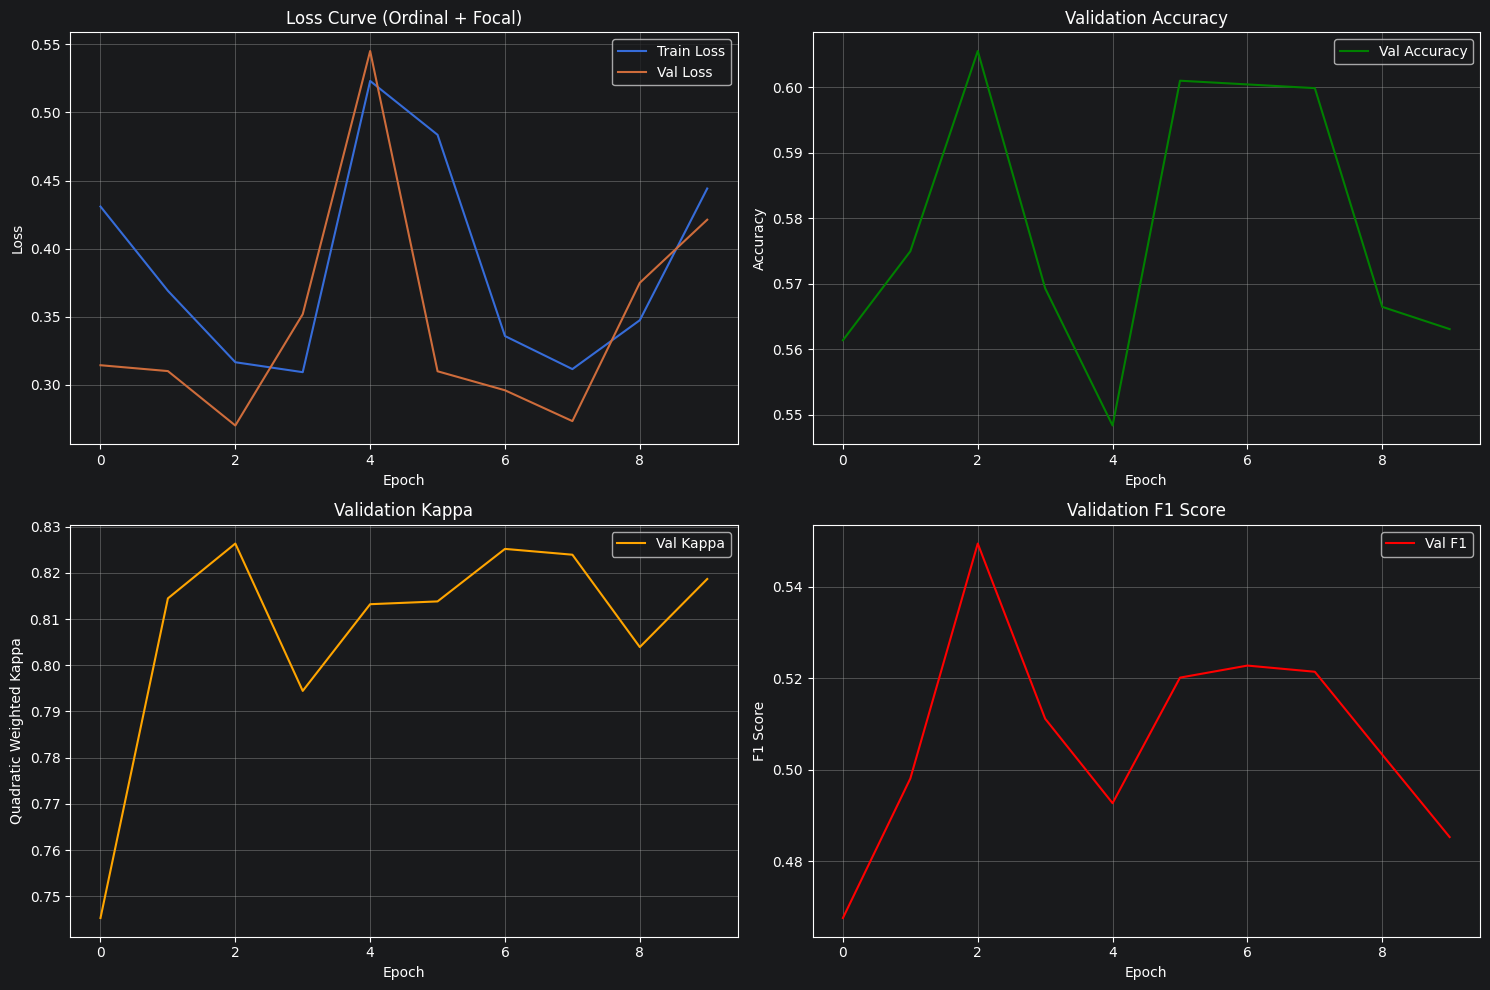

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss')
axes[0, 0].plot(history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curve (Ordinal + Focal)')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(history['val_acc'], label='Val Accuracy', color='green')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Kappa
axes[1, 0].plot(history['val_kappa'], label='Val Kappa', color='orange')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Quadratic Weighted Kappa')
axes[1, 0].set_title('Validation Kappa')
axes[1, 0].legend()
axes[1, 0].grid(True)

# F1 Score
axes[1, 1].plot(history['val_f1'], label='Val F1', color='red')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title('Validation F1 Score')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-focal-training.png', dpi=300, bbox_inches='tight')
plt.show()

## Evaluation on Test Set

Evaluating on test set...



Testing: 100%|██████████| 530/530 [07:59<00:00,  1.10it/s]



TEST SET RESULTS (Ordinal + Focal Loss)
Accuracy: 59.18%
Quadratic Weighted Kappa: 0.8088
Macro F1 Score: 0.5306

Classification Report:
              precision    recall  f1-score   support

      ISUP 0     0.7766    0.8571    0.8149       434
      ISUP 1     0.6605    0.6225    0.6409       400
      ISUP 2     0.4451    0.3850    0.4129       200
      ISUP 3     0.3693    0.3514    0.3601       185
      ISUP 4     0.3677    0.4385    0.4000       187
      ISUP 5     0.5926    0.5217    0.5549       184

    accuracy                         0.5918      1590
   macro avg     0.5353    0.5294    0.5306      1590
weighted avg     0.5889    0.5918    0.5888      1590


Confusion Matrix:
[[372  43   5   4   8   2]
 [ 71 249  51  23   6   0]
 [  7  58  77  42  15   1]
 [  6  15  30  65  56  13]
 [ 15   9   9  22  82  50]
 [  8   3   1  20  56  96]]


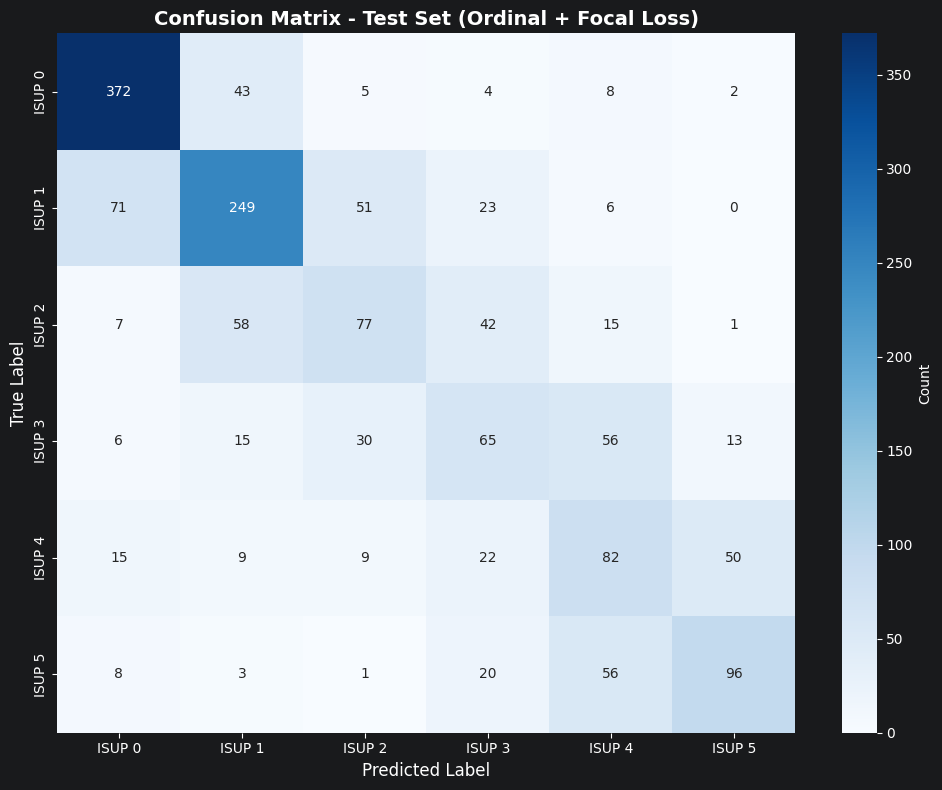


Test results saved to logs/b0-entropy-ordinal-focal-test-results.txt


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load best model
model.load_state_dict(torch.load(model_path, weights_only=True))
model.eval()

# Evaluate on test set
test_preds = []
test_targets = []

print("Evaluating on test set...\n")

with torch.no_grad():
    for batch_data, batch_targets, _ in tqdm(test_loader, desc="Testing"):
        batch_data = batch_data.to(device)
        
        # Forward pass
        logits = model(batch_data)
        
        # Decode predictions
        predictions = decode_ordinal_predictions(logits)
        
        # Convert ordinal targets to class labels
        targets_class = batch_targets.sum(dim=1).long()
        
        test_preds.append(predictions.cpu())
        test_targets.append(targets_class)

# Concatenate results
test_preds = torch.cat(test_preds).numpy()
test_targets = torch.cat(test_targets).numpy()

# Calculate metrics
test_accuracy = accuracy_score(test_targets, test_preds)
test_kappa = cohen_kappa_score(test_targets, test_preds, weights='quadratic')
test_f1 = f1_score(test_targets, test_preds, average='macro', zero_division=0)

print("\n" + "="*80)
print("TEST SET RESULTS (Ordinal + Focal Loss)")
print("="*80)
print(f"Accuracy: {test_accuracy*100:.2f}%")
print(f"Quadratic Weighted Kappa: {test_kappa:.4f}")
print(f"Macro F1 Score: {test_f1:.4f}")
print("="*80)

# Classification report
print("\nClassification Report:")
print(classification_report(test_targets, test_preds, target_names=[f'ISUP {i}' for i in range(6)], digits=4, zero_division=0))

# Confusion matrix
cm = confusion_matrix(test_targets, test_preds)
print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[f'ISUP {i}' for i in range(6)],
    yticklabels=[f'ISUP {i}' for i in range(6)],
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - Test Set (Ordinal + Focal Loss)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-focal-confusion-matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Save test results
with open('../logs/vit-entropy-ordinal-focal-test-results.txt', 'w') as f:
    f.write("ViT-B16 with Entropy Filtering, Ordinal Loss, and Focal Loss\n")
    f.write("="*80 + "\n\n")
    f.write(f"Test Accuracy: {test_accuracy*100:.2f}%\n")
    f.write(f"Test Quadratic Weighted Kappa: {test_kappa:.4f}\n")
    f.write(f"Test Macro F1 Score: {test_f1:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(test_targets, test_preds, target_names=[f'ISUP {i}' for i in range(6)], digits=4, zero_division=0))
    f.write("\nConfusion Matrix:\n")
    f.write(str(cm))

print("\nTest results saved to logs/b0-entropy-ordinal-focal-test-results.txt")

Evaluating on test set...



Testing: 100%|██████████| 530/530 [08:00<00:00,  1.10it/s]


Running bootstrap resampling...


Bootstrap: 100%|██████████| 1000/1000 [00:01<00:00, 543.40it/s]



TEST SET RESULTS (Ordinal + Focal Loss)
Accuracy :  59.18%  ±  1.18%  [95% CI: 56.92% – 61.64%]
QW Kappa :  0.8088  ±  0.0132  [95% CI: 0.7820 – 0.8326]
Macro F1 :  0.5306  ±  0.0123  [95% CI: 0.5055 – 0.5549]

Classification Report:
              precision    recall  f1-score   support

      ISUP 0     0.7766    0.8571    0.8149       434
      ISUP 1     0.6605    0.6225    0.6409       400
      ISUP 2     0.4451    0.3850    0.4129       200
      ISUP 3     0.3693    0.3514    0.3601       185
      ISUP 4     0.3677    0.4385    0.4000       187
      ISUP 5     0.5926    0.5217    0.5549       184

    accuracy                         0.5918      1590
   macro avg     0.5353    0.5294    0.5306      1590
weighted avg     0.5889    0.5918    0.5888      1590


Confusion Matrix:
[[372  43   5   4   8   2]
 [ 71 249  51  23   6   0]
 [  7  58  77  42  15   1]
 [  6  15  30  65  56  13]
 [ 15   9   9  22  82  50]
 [  8   3   1  20  56  96]]


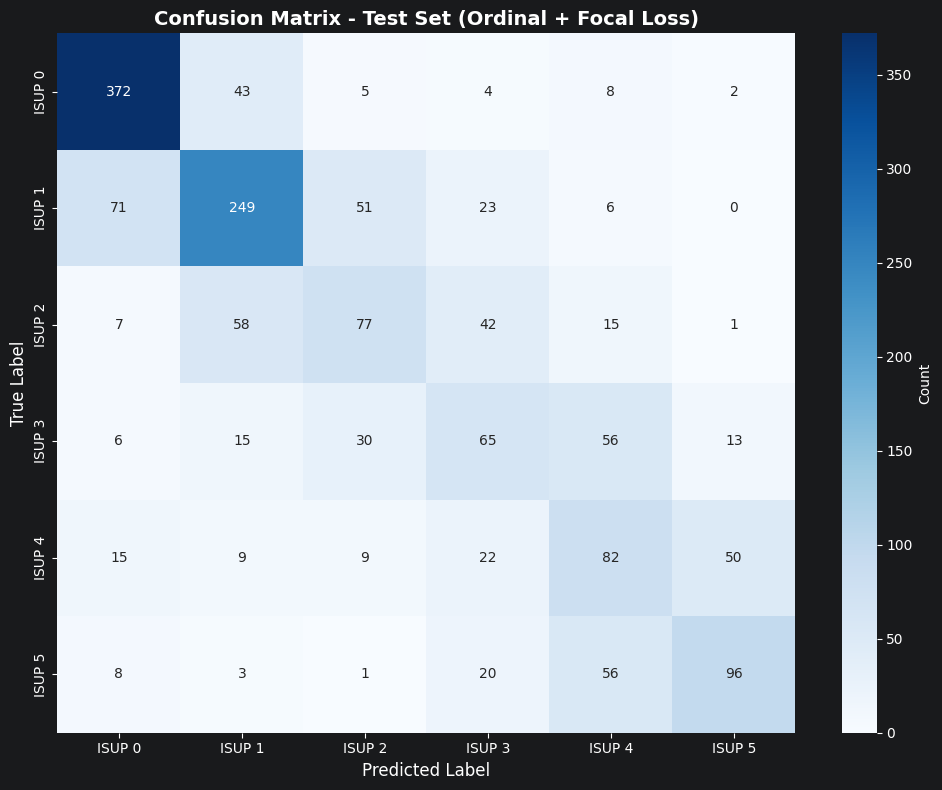


Test results saved to logs/vit-entropy-ordinal-focal-test-results.txt


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, cohen_kappa_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Load best model
model.load_state_dict(torch.load(model_path, weights_only=True))
model.eval()

# Evaluate on test set
test_preds = []
test_targets = []

print("Evaluating on test set...\n")

with torch.no_grad():
    for batch_data, batch_targets, _ in tqdm(test_loader, desc="Testing"):
        batch_data = batch_data.to(device)

        logits = model(batch_data)
        predictions = decode_ordinal_predictions(logits)
        targets_class = batch_targets.sum(dim=1).long()

        test_preds.append(predictions.cpu())
        test_targets.append(targets_class)

test_preds = torch.cat(test_preds).numpy()
test_targets = torch.cat(test_targets).numpy()

# ── Point estimates ───────────────────────────────────────────────────────────
test_accuracy = accuracy_score(test_targets, test_preds)
test_kappa    = cohen_kappa_score(test_targets, test_preds, weights='quadratic')
test_f1       = f1_score(test_targets, test_preds, average='macro', zero_division=0)

# ── Bootstrap (1 000 resamples) ───────────────────────────────────────────────
N_BOOTSTRAP = 1000
rng = np.random.default_rng(seed=42)
n   = len(test_targets)

boot_acc   = np.empty(N_BOOTSTRAP)
boot_kappa = np.empty(N_BOOTSTRAP)
boot_f1    = np.empty(N_BOOTSTRAP)

print("Running bootstrap resampling...")
for i in tqdm(range(N_BOOTSTRAP), desc="Bootstrap"):
    idx = rng.integers(0, n, size=n)
    y_true_b = test_targets[idx]
    y_pred_b = test_preds[idx]

    boot_acc[i]   = accuracy_score(y_true_b, y_pred_b)
    boot_kappa[i] = cohen_kappa_score(y_true_b, y_pred_b, weights='quadratic')
    boot_f1[i]    = f1_score(y_true_b, y_pred_b, average='macro', zero_division=0)

# ── Summary stats ─────────────────────────────────────────────────────────────
def boot_stats(arr):
    std     = arr.std(ddof=1)
    ci_low  = np.percentile(arr, 2.5)
    ci_high = np.percentile(arr, 97.5)
    return std, ci_low, ci_high

acc_std,   acc_ci_low,   acc_ci_high   = boot_stats(boot_acc)
kappa_std, kappa_ci_low, kappa_ci_high = boot_stats(boot_kappa)
f1_std,    f1_ci_low,    f1_ci_high    = boot_stats(boot_f1)

# ── Print results ─────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("TEST SET RESULTS (Ordinal + Focal Loss)")
print("="*80)
print(f"Accuracy :  {test_accuracy*100:.2f}%  ±  {acc_std*100:.2f}%  "
      f"[95% CI: {acc_ci_low*100:.2f}% – {acc_ci_high*100:.2f}%]")
print(f"QW Kappa :  {test_kappa:.4f}  ±  {kappa_std:.4f}  "
      f"[95% CI: {kappa_ci_low:.4f} – {kappa_ci_high:.4f}]")
print(f"Macro F1 :  {test_f1:.4f}  ±  {f1_std:.4f}  "
      f"[95% CI: {f1_ci_low:.4f} – {f1_ci_high:.4f}]")
print("="*80)

print("\nClassification Report:")
print(classification_report(test_targets, test_preds,
      target_names=[f'ISUP {i}' for i in range(6)], digits=4, zero_division=0))

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(test_targets, test_preds)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=[f'ISUP {i}' for i in range(6)],
    yticklabels=[f'ISUP {i}' for i in range(6)],
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - Test Set (Ordinal + Focal Loss)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('logs/vit-entropy-ordinal-focal-confusion-matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Save results ──────────────────────────────────────────────────────────────
with open('logs/vit-entropy-ordinal-focal-test-results.txt', 'w') as f:
    f.write("EfficientNet-B7 with Entropy Filtering, Ordinal Loss, and Focal Loss\n")
    f.write("="*80 + "\n\n")
    f.write(f"Bootstrap resamples : {N_BOOTSTRAP}\n\n")
    f.write(f"Accuracy  : {test_accuracy*100:.2f}% ± {acc_std*100:.2f}%  "
            f"[95% CI: {acc_ci_low*100:.2f}% – {acc_ci_high*100:.2f}%]\n")
    f.write(f"QW Kappa  : {test_kappa:.4f} ± {kappa_std:.4f}  "
            f"[95% CI: {kappa_ci_low:.4f} – {kappa_ci_high:.4f}]\n")
    f.write(f"Macro F1  : {test_f1:.4f} ± {f1_std:.4f}  "
            f"[95% CI: {f1_ci_low:.4f} – {f1_ci_high:.4f}]\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(test_targets, test_preds,
            target_names=[f'ISUP {i}' for i in range(6)], digits=4, zero_division=0))
    f.write("\nConfusion Matrix:\n")
    f.write(str(cm))

print("\nTest results saved to logs/vit-entropy-ordinal-focal-test-results.txt")

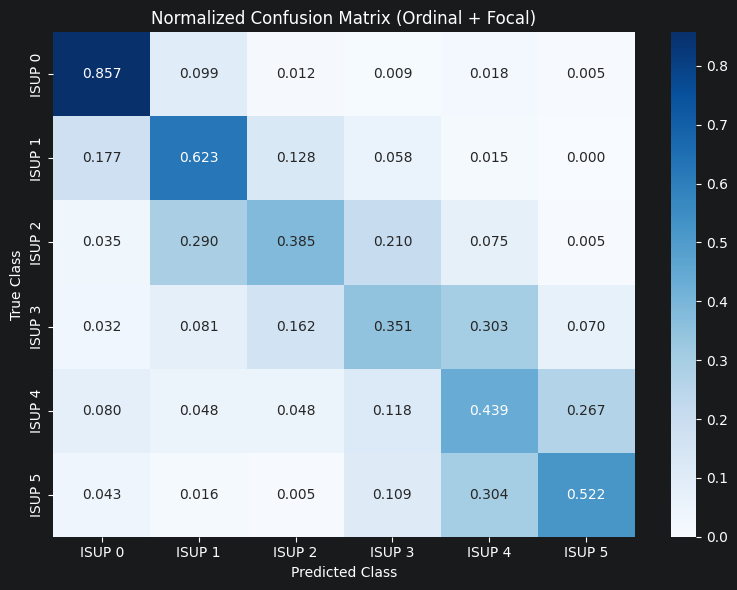

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Labels for classes
classes = ['ISUP 0', 'ISUP 1', 'ISUP 2', 'ISUP 3', 'ISUP 4', 'ISUP 5']

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)
plt.title("Normalized Confusion Matrix (Ordinal + Focal)")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-focal-confusion-matrix-normalized.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from utils.metrics import evaluation, format_metrics
model.load_state_dict(torch.load(model_path, weights_only=True))
response = evaluation(model, test_loader, device)
result = format_metrics(response[0])
print("\n=== TEST RESULTS B7 ===")
print(result)

100%|██████████| 530/530 [07:50<00:00,  1.13it/s]



=== TEST RESULTS B7 ===
VAL_ACC      Mean: 0.470 | Std: 0.012 | 95% CI: [0.451, 0.491]
VAL_KAPPA    Mean: 0.793 | Std: 0.012 | 95% CI: [0.774, 0.812]
VAL_F1       Mean: 0.450 | Std: 0.013 | 95% CI: [0.429, 0.472]
VAL_RECALL   Mean: 0.452 | Std: 0.013 | 95% CI: [0.431, 0.475]
VAL_PRECISION Mean: 0.489 | Std: 0.013 | 95% CI: [0.469, 0.510]
MEAN_ERROR   Mean: 0.678 | Std: 0.020 | 95% CI: [0.646, 0.709]


## Summary

This notebook trained ViT-B16 with a powerful combination of techniques:

1. **Entropy filtering** - Removed top 20% most difficult/ambiguous samples for cleaner training
2. **Ordinal loss** - Enforced the natural ordering of ISUP grades (0 < 1 < 2 < 3 < 4 < 5)
3. **Focal loss** - Down-weighted easy examples and focused learning on hard misclassifications

### How the combined loss works:

- **Ordinal encoding**: Each ISUP grade k is converted to k binary thresholds
  - ISUP 0: [0,0,0,0,0]
  - ISUP 3: [1,1,1,0,0] (grade > 0, > 1, > 2, but not > 3 or > 4)

- **Focal modulation**: Applied to each binary threshold prediction
  - Easy predictions (high confidence): Down-weighted by factor (1-p)^gamma
  - Hard predictions (low confidence): Retain full weight
  - Result: Model focuses on learning difficult threshold boundaries

### Expected benefits:

- Better handling of class imbalance (fewer high-grade samples)
- Reduced impact of easy negative examples
- Improved performance on minority classes (ISUP 4-5)
- Maintained ordinal consistency in predictions